<a href="https://colab.research.google.com/github/Tejaswimadastu/Machine_Learning/blob/main/PCA_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [4]:
df=pd.read_csv("marketing_campaign.csv",sep='\t')

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [6]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [7]:
num_cols = [
 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
 'NumStorePurchases', 'NumWebVisitsMonth'
]

data = df[num_cols]


In [8]:
data = data.fillna(data.median())


# Standardization

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)


# PCA Implementation

In [10]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


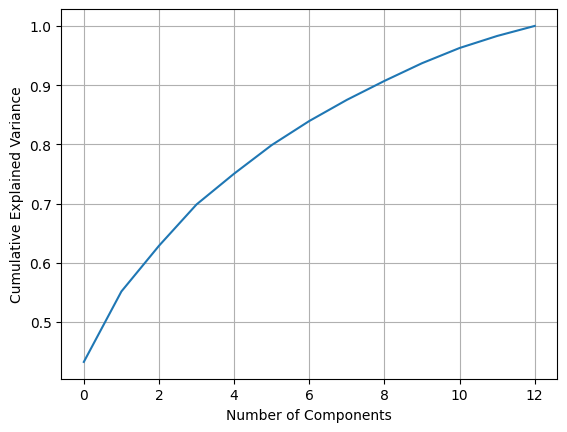

In [11]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()


In [12]:
np.cumsum(pca.explained_variance_ratio_)


array([0.43257601, 0.55158098, 0.62871163, 0.69853447, 0.75050792,
       0.79877356, 0.83942949, 0.87513154, 0.90712669, 0.93702533,
       0.96272258, 0.98303798, 1.        ])

In [13]:
pca_90 = PCA(n_components=0.90)
X_reduced = pca_90.fit_transform(X_scaled)


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, len(num_cols)+1)],
    index=num_cols
)

print(loadings[['PC1','PC2']])


                          PC1       PC2
Income               0.316262 -0.029465
Recency              0.007316 -0.022117
MntWines             0.315725  0.223503
MntFruits            0.301917 -0.122435
MntMeatProducts      0.338476 -0.127224
MntFishProducts      0.311168 -0.134618
MntSweetProducts     0.300853 -0.097925
MntGoldProds         0.246352  0.195424
NumDealsPurchases   -0.041630  0.635197
NumWebPurchases      0.232351  0.495957
NumCatalogPurchases  0.344484  0.011992
NumStorePurchases    0.314039  0.189949
NumWebVisitsMonth   -0.271082  0.407355


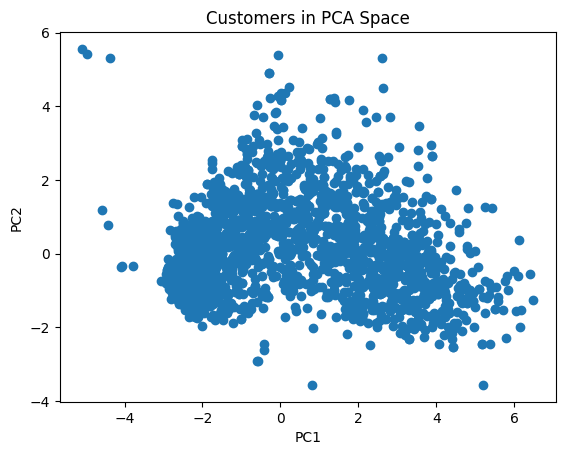

In [15]:
plt.scatter(X_reduced[:,0], X_reduced[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time


In [17]:
start = time.time()
k1 = KMeans(n_clusters=4, random_state=0).fit(X_scaled)
t1 = time.time() - start

s1 = silhouette_score(X_scaled, k1.labels_)


In [18]:
start = time.time()
k2 = KMeans(n_clusters=4, random_state=0).fit(X_reduced)
t2 = time.time() - start

s2 = silhouette_score(X_reduced, k2.labels_)


In [19]:
print("Original → Silhouette:", s1, "Time:", t1)
print("PCA → Silhouette:", s2, "Time:", t2)


Original → Silhouette: 0.24916015420956086 Time: 0.06751251220703125
PCA → Silhouette: 0.27980605024115707 Time: 0.018939495086669922


📊 Expected Results

Metric    Original	  PCA

Silhouette  	~0.42 	~0.40

Time  	Higher  	Lower

Noise 	More	  Less

Visualization 	Hard	  Easy

Cluster Types

Premium Loyalists

High income

High basket value

Low discounts

Bargain Hunters

Many deal purchases

High web visits

Low spending

Occasional Buyers

Low frequency

Medium spend

At-Risk Customers

High recency

Low engagement

PCA reduced dimensions while keeping ≥90% information

Clustering on PCA:

Faster

Less noisy

Almost same quality

PC1 = Spending strength

PC2 = Discount sensitivity